### Классификация снимков КТ с помощью свёрточных нейронных сетей

#### Импорт TensorFlow и других библиотек

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
print(tf.__version__)

2.4.0


#### 1. Загрузка и просмотр датасета

В этом уроке используется датасет из 2560 фотографий снимков КТ. Датасет состоит из 2-ти директорий:

```
data/
  CT_Covid-19/
  CT_Non_Covid-19/
```

In [ ]:
import pathlib
from google.colab import drive
drive.mount('/content/drive')
data_dir = pathlib.Path('/content/drive/MyDrive/data')
print(data_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/data


После загрузки доступна копия датасета. Всего 2560 изображений:

In [ ]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

2560


Посмотрим изображения из директории Not_Infected:

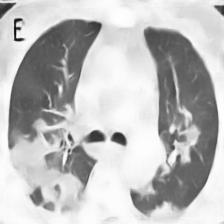

In [ ]:
infected = list(data_dir.glob('CT_Covid-19/*'))
PIL.Image.open(str(infected[2]))

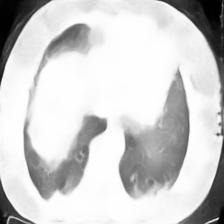

In [ ]:
PIL.Image.open(str(infected[5]))

И из Infected:

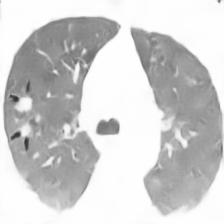

In [ ]:
not_infected = list(data_dir.glob('CT_Non_Covid-19/*'))
PIL.Image.open(str(not_infected[0]))

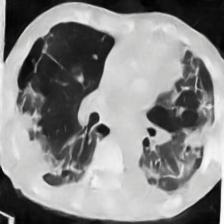

In [ ]:
PIL.Image.open(str(not_infected[1]))

#### Загрузка с диска с использованием keras.preprocessing

Давайте загрузим изображения с диска с помощью утилиты [image_dataset_from_directory](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory). Этот помощник создаст `tf.data.Dataset` всего-лишь несколькими строчками кода. Или, если вам нравится, вы можете создать загрузчик изображений с нуля, используя [load images](https://www.tensorflow.org/tutorials/load_data/images).

#### 2. Создание датасета

Определим параметры для загрузки изображения:

In [ ]:
batch_size = 32
img_height = 180
img_width = 180

Считается хорошей практикой использовать проверочный сет при обучении модели. Мы будем использовать 80% изображений для тренировки, и 20% для проверки.

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2560 files belonging to 2 classes.
Using 2048 files for training.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2560 files belonging to 2 classes.
Using 512 files for validation.


Вы можете посмотреть классы датасета в аттрибуте `class_names`. В данном случае они соответствуют именам директорий и отсортированы в алфавитном порядке.

In [ ]:
class_names = train_ds.class_names
print(class_names)

['CT_Covid-19', 'CT_Non_Covid-19']


#### 3. Визуализация данных

Первые 9 изображений из тренировочного датасета.

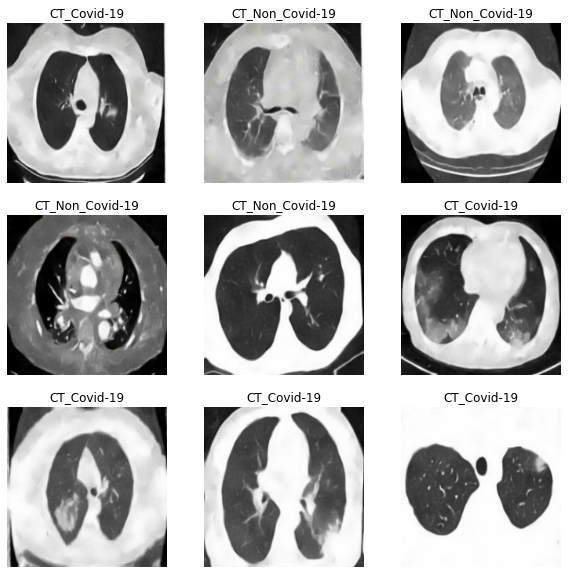

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

Вы будет отправлять эти датасеты в метод `model.fit` вашей модели. Вы также можете пройти методом for по датасету и посмотреть на пакет, возвращаемый датасетом:

In [ ]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


`image_batch` это тензор размерности `(32, 180, 180, 3)`. В данном примере: `32` - размер пакета, `180х180` - размер изображения, `3` - количество цветовых каналов(RGB). `label_batch` - тензор размерности `(32,)`, в данном примере содержит 32 метки для изображений. 

Вы моежет вызвать метод `.numpy()` на `image_batch` и `labels_batch` тензорах, чтобы преобразовать их в `numpy.ndarray`.


#### 4. Конфигурирование датасета для улучшения производительности

Обязательно используйте буферизованную предварительную выборку, чтобы мы могли читать данные с диска без блокировки ввода/вывода. Вот два важных метода, которые вы должны использовать при загрузке данных.

`Dataset.cache()` сохраняет изображения в памяти после их загрузки с диска в течение первой эпохи. Это гарантирует, что загрузка данных не станет узким местом при обучении вашей модели. Если ваш набор данных слишком большой и не помещается в память, вы также можете использовать этот метод для создания дискового кеша..

`Dataset.prefetch()` перекрывает предварительную обработку данных и выполнение модели во время обучения за счет предварительной выборки.


In [ ]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

#### 5. Нормирование данных

The RGB channel values are in the `[0, 255]` range. This is not ideal for a neural network; in general you should seek to make your input values small. Here, we will standardize values to be in the `[0, 1]` by using a Rescaling layer.

Значения канала RGB находятся в диапазоне `[0, 255]`. Это не идеально для нейронной сети, вы должны стремиться к тому, чтобы ваши входные значения были небольшими. Далее мы нормализуем значения, чтобы они находились в диапазоне `[0, 1]`, используя слой Rescaling.

In [ ]:
normalization_layer = layers.experimental.preprocessing.Rescaling(1./255)

Примечание. Утилиты и слои Keras Preprocesing, описанные в этом разделе, в настоящее время являются экспериментальными и могут измениться.

Существует два способа использовать слой Rescaling. Вы можете применить его к набору данных, вызвав метод map:

In [ ]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Обратите внимание, что значения пикселей теперь находятся в `[0,1]`.
print(np.min(first_image), np.max(first_image)) 

0.0 0.97813183


Или вы можете включить слой непосредственно в модель, что упростит развертывание. Дальше мы воспользуемся вторым подходом.

Примечание: ранее мы изменяли размер изображений используя аргумент `image_size` метода `image_dataset_from_directory`. Если вы хотите включить изменения размера в свою модель, вы можете использовать слой [Resizing](https://www.tensorflow.org/api_docs/python/tf/keras/layers/experimental/preprocessing/Resizing).

#### 6. Создание модели

Модель состоит из трех сверточных слоев Conv2D с MaxPooling2D слоем в каждом из них. Далее следует полносвязанный слой со 128 входными параметрами, который активируется функцией активации `relu`. Эта модель не настроена для обеспечения высокой точности, цель этого руководства - показать стандартный подход.

In [ ]:
num_classes = 5

model = Sequential([
  layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

#### 7. Отладка модели

Для этого урока выберем оптимайзер `optimizers.Adam` и функцию потерь `losses.SparseCategoricalCrossentropy`. Для просмотра тренировочной и проверочной точности на каждой эпохе, передадим аргумент `metrics`.

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#### 8. Структура модели

Для просмотра всех слоев модели используйте метод `summary`:

In [ ]:
model.summary()

Model: "sequential_20"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
rescaling_20 (Rescaling)     (None, 180, 180, 3)       0         
_________________________________________________________________
conv2d_51 (Conv2D)           (None, 180, 180, 16)      448       
_________________________________________________________________
max_pooling2d_51 (MaxPooling (None, 90, 90, 16)        0         
_________________________________________________________________
conv2d_52 (Conv2D)           (None, 90, 90, 32)        4640      
_________________________________________________________________
max_pooling2d_52 (MaxPooling (None, 45, 45, 32)        0         
_________________________________________________________________
conv2d_53 (Conv2D)           (None, 45, 45, 64)        18496     
_________________________________________________________________
max_pooling2d_53 (MaxPooling (None, 22, 22, 64)      

#### 9. Обучение модели

In [ ]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
64/64 [==============================] - 2s 23ms/step - loss: 0.9675 - accuracy: 0.5803 - val_loss: 0.4635 - val_accuracy: 0.7676
Epoch 2/10
64/64 [==============================] - 1s 21ms/step - loss: 0.3871 - accuracy: 0.8114 - val_loss: 0.4516 - val_accuracy: 0.7656
Epoch 3/10
64/64 [==============================] - 1s 21ms/step - loss: 0.2915 - accuracy: 0.8703 - val_loss: 0.2902 - val_accuracy: 0.8633
Epoch 4/10
64/64 [==============================] - 1s 20ms/step - loss: 0.1923 - accuracy: 0.9308 - val_loss: 0.2342 - val_accuracy: 0.9023
Epoch 5/10
64/64 [==============================] - 1s 23ms/step - loss: 0.1069 - accuracy: 0.9648 - val_loss: 0.1977 - val_accuracy: 0.9180
Epoch 6/10
64/64 [==============================] - 1s 20ms/step - loss: 0.0649 - accuracy: 0.9800 - val_loss: 0.1995 - val_accuracy: 0.9160
Epoch 7/10
64/64 [==============================] - 1s 20ms/step - loss: 0.0404 - accuracy: 0.9893 - val_loss: 0.1686 - val_accuracy: 0.9492
Epoch 8/10
64

#### 10. Визуализация результатов

Построим графики потерь и точности для тренировочных и проверочных данных

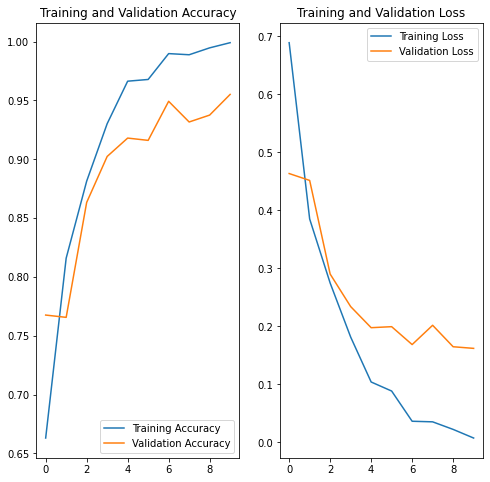

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Как вы можете видеть на графиках, точность проверки ниже точности обучения, и модель достигла всего-лишь около 95% точности на проверочных данных.

Давайте посмотрим, что пошло не так, и попробуем повысить общую производительность модели.

#### 11. Переобучение(Overfitting)

На графиках выше точность обучения линейно увеличивается со временем, тогда как точность проверки в процессе обучения составляет 95%. Разница между точностью обучения и точностью проверки - признак [переобучения](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit).

Когда модель обучается на небольшом количестве данных, она начинает учиться на шумах или нежелательных деталях обучающих примеров. До такой степени, что это отрицательно влияет на точность модели на новых примерах. Это явление известно как переобучение. Это значит, что модели будет сложно обобщить новый набор данных.

Есть несколько способов борьбы с переобучением в тренировочном процессе. В этом руководстве вы будете использовать *увеличение данных* и добавление *Dropout* в свою модель.

#### 12. Расширение набора данных(Data augmentation)

Переобучение обычно происходит при небольшом количестве обучающих примеров. [Увеличение данных](https://www.tensorflow.org/tutorials/images/data_augmentation) использует подход, основанный на создании дополнительных обучающих данных из существующих примеров, путем использования случайных преобразований, которые дают правдоподобные изображения. Это дает возможность модели потренироваться на большем количестве данных и лучше обобщить.

Для аугментации данных мы будем использовать [Keras Preprocessing Layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/experimental/preprocessing/?version=nightly). Слои предварительной обработки(Keras Preprocessing Layers) могут быть включены в вашу модель, как и другие слои, и запускаться на графическом процессоре.

In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal", 
                                                 input_shape=(img_height, 
                                                              img_width,
                                                              3)),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1),
  ]
)

Давайте визуализируем несколько примеров, созданных с помощью Keras Preprocessing Layers:

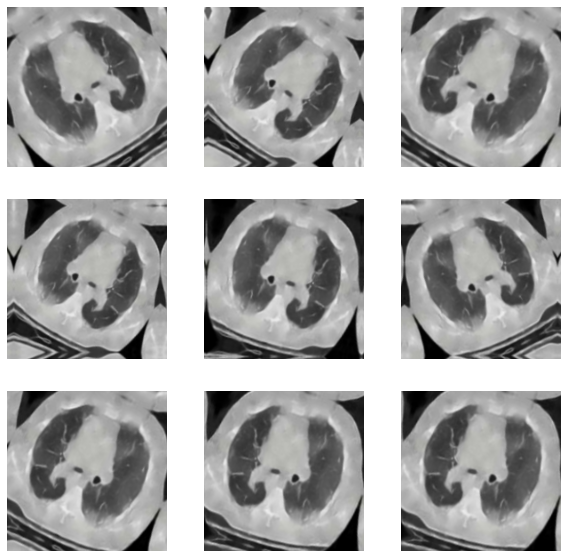

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

Мы используем аугментацию данных и заново обучим модель

#### 13. Исключение из обучения(Dropout)

Еще один метод уменьшения переобучения - добавить в модель [Dropout](https://developers.google.com/machine-learning/glossary#dropout_regularization) как форму *регуляризации*.

Когда вы применяете Dropout к слою, он случайным образом исключает из слоя(путем установки активации на ноль) некоторое количество выходных единиц во время процесса обучения. Dropout принимает дробное число в качестве входного значения, например 0.1, 0.2, 0.4 и т.д. Это означает случайное исключение 10%, 20% или 40% выходных единиц из применяемого слоя.

Давайте создадим новую нейронную сеть, используя `layers.Dropout`, а затем обучим ее, используя созданные с помощью аугментации изображения.

In [ ]:
model = Sequential([
  data_augmentation,
  layers.experimental.preprocessing.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

#### 14. Отладка и обучение модели

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_24"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_21 (Sequential)   (None, 180, 180, 3)       0         
_________________________________________________________________
rescaling_23 (Rescaling)     (None, 180, 180, 3)       0         
_________________________________________________________________
conv2d_60 (Conv2D)           (None, 180, 180, 16)      448       
_________________________________________________________________
max_pooling2d_60 (MaxPooling (None, 90, 90, 16)        0         
_________________________________________________________________
conv2d_61 (Conv2D)           (None, 90, 90, 32)        4640      
_________________________________________________________________
max_pooling2d_61 (MaxPooling (None, 45, 45, 32)        0         
_________________________________________________________________
conv2d_62 (Conv2D)           (None, 45, 45, 64)      

In [ ]:
epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
64/64 [==============================] - 3s 29ms/step - loss: 0.9465 - accuracy: 0.4875 - val_loss: 0.6303 - val_accuracy: 0.6348
Epoch 2/10
64/64 [==============================] - 2s 27ms/step - loss: 0.6486 - accuracy: 0.6020 - val_loss: 0.5785 - val_accuracy: 0.7031
Epoch 3/10
64/64 [==============================] - 2s 27ms/step - loss: 0.6136 - accuracy: 0.6546 - val_loss: 0.5478 - val_accuracy: 0.7168
Epoch 4/10
64/64 [==============================] - 2s 27ms/step - loss: 0.5907 - accuracy: 0.6888 - val_loss: 0.5363 - val_accuracy: 0.7051
Epoch 5/10
64/64 [==============================] - 2s 27ms/step - loss: 0.5874 - accuracy: 0.7258 - val_loss: 0.4992 - val_accuracy: 0.7598
Epoch 6/10
64/64 [==============================] - 2s 27ms/step - loss: 0.5536 - accuracy: 0.7220 - val_loss: 0.5289 - val_accuracy: 0.7305
Epoch 7/10
64/64 [==============================] - 2s 27ms/step - loss: 0.5374 - accuracy: 0.7046 - val_loss: 0.5074 - val_accuracy: 0.7363
Epoch 8/10
64

#### 15. Визуализация результатов

После применения аугментации данных и слоя `Dropout` переобучение уменьшилось, а точность тренировки и точность проверки стали гораздо ближе.

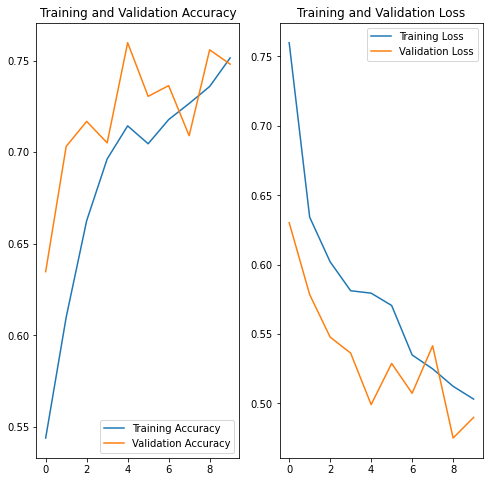

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### 16. Предсказание на новых данных

Проверим как модель классифицирует изображение, которого не было ни в тренировочных, ни в проверочных данных.

Примечание: Аугментация данных и `Dropout` неактивны во время получения предсказаний(метод predict).

In [ ]:
data_dir = '/content/drive/MyDrive/covid.jpg'
data_dir = pathlib.Path(data_dir)

img = keras.preprocessing.image.load_img(
    data_dir, target_size=(img_height, img_width)
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "Снимок относитчя к {} с {:.2f} % вероятности."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

This image most likely belongs to CT_Non_Covid-19 with a 96.89 percent confidence.
